In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
pip install torch transformers datasets matplotlib seaborn tqdm scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [63]:
# =============================
# 1. IMPORTS
# =============================
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from torch.cuda.amp import autocast,GradScaler


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [64]:
# =============================
# 2. LOAD CSV (YOUR DATASET)
# =============================
df = pd.read_csv("/kaggle/input/datasets/otaku09/tweets/Tweets (1).csv")  # 🔁 change path

# Clean columns
df.columns = df.columns.str.strip().str.lower()

# Keep required columns
df = df[['text', 'sentiment']]

# Map labels (3 classes)
label_map = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

df['label'] = df['sentiment'].map(label_map)

# Remove missing
df = df.dropna()

print(df.head())
print(df['label'].value_counts())

                                                text sentiment  label
0                I`d have responded, if I were going   neutral      1
1      Sooo SAD I will miss you here in San Diego!!!  negative      0
2                          my boss is bullying me...  negative      0
3                     what interview! leave me alone  negative      0
4   Sons of ****, why couldn`t they put them on t...  negative      0
label
1    11117
2     8582
0     7781
Name: count, dtype: int64


In [65]:
# =============================
# 3. CUSTOM DATASET
# =============================
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [66]:
# =============================
# 4. SPLIT DATA
# =============================
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].tolist(),
    df['label'].tolist(),
    test_size=0.1,
    random_state=42
)

In [67]:
import torch
torch.cuda.empty_cache()

In [68]:
# =============================
# 5. TOKENIZER + LOADERS
# =============================
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_dataset = TextDataset(train_texts, train_labels, tokenizer)
val_dataset = TextDataset(val_texts, val_labels, tokenizer)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,           # 🔥 larger batch
    shuffle=True,
    num_workers=2,           # 🔥 faster loading
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    num_workers=2,
    pin_memory=True
)

In [69]:
# =============================
# 6. MODEL
# =============================
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3,
    output_attentions=True
)


model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [70]:
# =============================
# 7. OPTIMIZER
# =============================
optimizer = AdamW(model.parameters(), lr=2e-5)
scaler=GradScaler()

/tmp/ipykernel_57/1899245901.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=GradScaler()


In [45]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

/tmp/ipykernel_57/3522360610.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [71]:
# =============================
# TRAINING (FINAL FIXED)
# =============================
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()
epochs = 2

for epoch in range(epochs):
    model.train()
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for batch in loop:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device, non_blocking=True)
        attention_mask = batch['attention_mask'].to(device, non_blocking=True)
        labels = batch['labels'].to(device, non_blocking=True)

        with autocast():   # ✅ old API
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss if hasattr(outputs, "loss") else outputs[0]

            # 🔥 IMPORTANT FIX
            if loss.dim() > 0:
                loss = loss.mean()

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loop.set_postfix(loss=loss.item())

/tmp/ipykernel_57/341607183.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1:   0%|          | 0/3092 [00:00<?, ?it/s]/tmp/ipykernel_57/341607183.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():   # ✅ old API
Epoch 2: 100%|██████████| 3092/3092 [04:38<00:00, 11.10it/s, loss=0.374] 


In [72]:
# =============================
# 9. EVALUATION
# =============================
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for batch in tqdm(val_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits if hasattr(outputs, "logits") else outputs[0]

        preds = torch.argmax(logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Validation Accuracy:", correct / total)

100%|██████████| 344/344 [00:10<00:00, 32.22it/s]

Validation Accuracy: 0.7900291120815138


In [74]:
# =============================
# 10. ATTENTION HEATMAP
# =============================
def plot_attention(sentence):
    model.eval()

    inputs = tokenizer(sentence, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    attentions = outputs.attentions
    attn = attentions[-1][0]

    attn_matrix = attn.mean(dim=0).cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    plt.figure(figsize=(10,8))
    sns.heatmap(attn_matrix, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
    plt.xticks(rotation=90)
    plt.title("Attention Heatmap")
    plt.show()

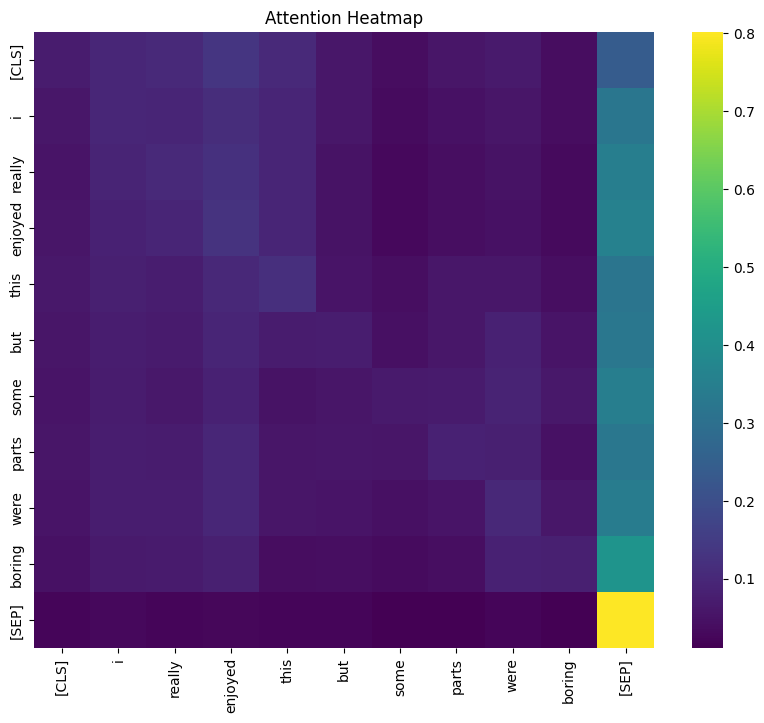

In [75]:
plot_attention("I really enjoyed this but some parts were boring")